# Trabajo individual — Spotify, The Smiths y letras

Este notebook está preparado para ejecutarse directamente en Google Colab sin clonar repositorios ni depender de archivos externos del proyecto.

## Objetivos del trabajo

1. Filtrar los álbumes de The Smiths para conservar solo álbumes de estudio.
2. Crear gráficos relacionados con letras de canciones usando `lyrics.ovh`.
3. Indicar la web app Streamlit desarrollada para explorar los componentes.

## 1. Instalación de librerías

Esta instalación se realiza solo dentro del entorno temporal de Colab. No instala nada en el ordenador.

In [1]:
!pip install -q gdown wordcloud requests pandas matplotlib

## 2. Carga del dataset

Se utiliza el fichero `tracks_features.csv` del dataset Spotify 1.2M+ Songs.  
El notebook lo descarga automáticamente usando el mismo identificador de Google Drive que aparecía en el ejemplo base.

In [2]:
import os
import re
import ast
import time
from collections import Counter

import gdown
import pandas as pd
import matplotlib.pyplot as plt
import requests
from wordcloud import WordCloud
from IPython.display import display

DATA_FILE = "tracks_features.csv"
GDRIVE_FILE_ID = "1jsXTNtGhOrsCApQctYx-hRxAQASAcPlI"

if not os.path.exists(DATA_FILE):
    print("Descargando dataset...")
    gdown.download(f"https://drive.google.com/uc?id={GDRIVE_FILE_ID}", DATA_FILE, quiet=False)
else:
    print("Dataset ya existe en Colab.")

df = pd.read_csv(DATA_FILE)

print("Dimensiones:", df.shape)
print("Columnas:")
print(df.columns.tolist())

display(df.head())

Dataset ya existe en Colab.
Dimensiones: (1204025, 24)
Columnas:
['id', 'name', 'album', 'album_id', 'artists', 'artist_ids', 'track_number', 'disc_number', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'year', 'release_date']


,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],1,1,False,0.470,...,0.0727,0.02610,0.000011,0.3560,0.503,117.906,210133,4.0,1999,1999-11-02
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],2,1,True,0.599,...,0.1880,0.01290,0.000071,0.1550,0.489,103.680,206200,4.0,1999,1999-11-02
2,1hR0fIFK2qRG3f3RF70pb7,Calm Like a Bomb,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],3,1,False,0.315,...,0.4830,0.02340,0.000002,0.1220,0.370,149.749,298893,4.0,1999,1999-11-02
3,2lbASgTSoDO7MTuLAXlTW0,Mic Check,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],4,1,True,0.440,...,0.2370,0.16300,0.000004,0.1210,0.574,96.752,213640,4.0,1999,1999-11-02
4,1MQTmpYOZ6fcMQc56Hdo7T,Sleep Now In the Fire,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],5,1,False,0.426,...,0.0701,0.00162,0.105000,0.0789,0.539,127.059,205600,4.0,1999,1999-11-02


## 3. Filtrado exacto del artista

Inicialmente se comprobó que buscar `"The Smiths"` con `str.contains()` generaba falsos positivos, por ejemplo `The Smithsonian Chamber Players`.  
Por eso aquí se usa un filtro exacto sobre la lista de artistas.

In [3]:
TARGET_ARTIST_NAME = "The Smiths"

def parse_possible_list(value):
    if pd.isna(value):
        return []
    text = str(value)
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed]
        return [str(parsed).strip()]
    except Exception:
        return [text.strip()]

def artist_exact_match(artists_value, target_artist):
    artists = parse_possible_list(artists_value)
    return any(a.lower().strip() == target_artist.lower() for a in artists)

contains_mask = df["artists"].astype(str).str.contains(TARGET_ARTIST_NAME, case=False, na=False)
exact_mask = df["artists"].apply(lambda x: artist_exact_match(x, TARGET_ARTIST_NAME))

contains_df = df[contains_mask].copy()
smiths_df = df[exact_mask].copy()

print(f"Filas encontradas con str.contains('The Smiths'): {len(contains_df)}")
print(f"Filas encontradas con artista exacto 'The Smiths': {len(smiths_df)}")
print(f"Posibles falsos positivos: {len(contains_df) - len(smiths_df)}")

display(smiths_df[["name", "album", "artists", "year"]].sort_values(["year", "album", "name"]))

Filas encontradas con str.contains('The Smiths'): 44
Filas encontradas con artista exacto 'The Smiths': 11
Posibles falsos positivos: 33


,name,album,artists,year
517316,A Rush and a Push and the Land Is Ours - 2011 ...,"Strangeways, Here We Come",['The Smiths'],1987
517324,Death at One's Elbow - 2011 Remaster,"Strangeways, Here We Come",['The Smiths'],1987
517318,Death of a Disco Dancer - 2011 Remaster,"Strangeways, Here We Come",['The Smiths'],1987
517319,Girlfriend in a Coma - 2011 Remaster,"Strangeways, Here We Come",['The Smiths'],1987
517317,I Started Something I Couldn't Finish - 2011 R...,"Strangeways, Here We Come",['The Smiths'],1987
517325,I Won't Share You - 2011 Remaster,"Strangeways, Here We Come",['The Smiths'],1987
517321,Last Night I Dreamt That Somebody Loved Me - 2...,"Strangeways, Here We Come",['The Smiths'],1987
517323,Paint a Vulgar Picture - 2011 Remaster,"Strangeways, Here We Come",['The Smiths'],1987
517320,Stop Me If You Think You've Heard This One Bef...,"Strangeways, Here We Come",['The Smiths'],1987
517322,Unhappy Birthday - 2011 Remaster,"Strangeways, Here We Come",['The Smiths'],1987


## 4. Álbumes encontrados antes del filtrado

Esta tabla muestra qué publicaciones aparecen en el dataset para The Smiths como artista exacto.

In [4]:
albums_before = (
    smiths_df
    .groupby("album")
    .agg(canciones=("name", "count"), year=("year", "min"))
    .sort_values(["year", "album"])
)

display(albums_before)

,canciones,year
album,,
"Strangeways, Here We Come",10,1987
The Wedding Singer (Music From The Motion Picture),1,1998


## 5. Filtrado de álbumes de estudio

Según la discografía oficial de The Smiths, sus álbumes de estudio son:

- The Smiths
- Meat Is Murder
- The Queen Is Dead
- Strangeways, Here We Come

Al aplicar el filtro al dataset usado, solo aparecen canciones originales del álbum `Strangeways, Here We Come`.  
Esto no significa que el filtro esté mal, sino que el dataset no contiene los otros tres álbumes interpretados por The Smiths.

In [5]:
def normalize_album_name(album):
    album = str(album)
    album = re.sub(r"\(.*?\)", "", album)
    album = re.sub(r"\[.*?\]", "", album)
    album = re.sub(r"\s*-\s*.*Remaster.*$", "", album, flags=re.IGNORECASE)
    album = re.sub(r"\s*-\s*.*Deluxe.*$", "", album, flags=re.IGNORECASE)
    album = re.sub(r"\s*-\s*.*Edition.*$", "", album, flags=re.IGNORECASE)
    album = re.sub(r"\s+", " ", album).strip()
    return album

STUDIO_ALBUMS = [
    "The Smiths",
    "Meat Is Murder",
    "The Queen Is Dead",
    "Strangeways, Here We Come"
]

smiths_df["short_album_name"] = smiths_df["album"].apply(normalize_album_name)

studio_df = smiths_df[smiths_df["short_album_name"].isin(STUDIO_ALBUMS)].copy()

studio_df = (
    studio_df
    .sort_values(["year", "short_album_name", "track_number", "name"])
    .drop_duplicates(subset=["short_album_name", "name"], keep="first")
    .reset_index(drop=True)
)

album_counts = []
for album in STUDIO_ALBUMS:
    count = int((studio_df["short_album_name"] == album).sum())
    album_counts.append({"album": album, "canciones": count})

album_counts_df = pd.DataFrame(album_counts)

print(f"Total de canciones después de filtrar álbumes de estudio: {len(studio_df)}")
display(album_counts_df)

display(studio_df[["track_number", "name", "short_album_name", "album", "year"]])

Total de canciones después de filtrar álbumes de estudio: 10


,album,canciones
0,The Smiths,0
1,Meat Is Murder,0
2,The Queen Is Dead,0
3,"Strangeways, Here We Come",10


,track_number,name,short_album_name,album,year
0,1,A Rush and a Push and the Land Is Ours - 2011 ...,"Strangeways, Here We Come","Strangeways, Here We Come",1987
1,2,I Started Something I Couldn't Finish - 2011 R...,"Strangeways, Here We Come","Strangeways, Here We Come",1987
2,3,Death of a Disco Dancer - 2011 Remaster,"Strangeways, Here We Come","Strangeways, Here We Come",1987
3,4,Girlfriend in a Coma - 2011 Remaster,"Strangeways, Here We Come","Strangeways, Here We Come",1987
4,5,Stop Me If You Think You've Heard This One Bef...,"Strangeways, Here We Come","Strangeways, Here We Come",1987
5,6,Last Night I Dreamt That Somebody Loved Me - 2...,"Strangeways, Here We Come","Strangeways, Here We Come",1987
6,7,Unhappy Birthday - 2011 Remaster,"Strangeways, Here We Come","Strangeways, Here We Come",1987
7,8,Paint a Vulgar Picture - 2011 Remaster,"Strangeways, Here We Come","Strangeways, Here We Come",1987
8,9,Death at One's Elbow - 2011 Remaster,"Strangeways, Here We Come","Strangeways, Here We Come",1987
9,10,I Won't Share You - 2011 Remaster,"Strangeways, Here We Come","Strangeways, Here We Come",1987


### Comentario

Como tres de los cuatro álbumes de estudio no tienen canciones disponibles en este dataset, los gráficos principales se hacen **por canción**, no por álbum.  
Esto permite obtener visualizaciones más útiles con las canciones realmente disponibles.

In [6]:
studio_df["clean_name"] = (
    studio_df["name"]
    .astype(str)
    .str.replace(r"\s*-\s*2011 Remaster.*$", "", regex=True)
    .str.replace(r"\s*-\s*Remaster.*$", "", regex=True)
)

studio_df_plot = studio_df.sort_values("track_number").copy()

display(studio_df_plot[["track_number", "clean_name", "energy", "valence", "danceability", "acousticness", "tempo", "duration_ms"]])

,track_number,clean_name,energy,valence,danceability,acousticness,tempo,duration_ms
0,1,A Rush and a Push and the Land Is Ours,0.640,0.6330,0.670,0.11400,110.140,183013
1,2,I Started Something I Couldn't Finish,0.851,0.7030,0.581,0.11200,135.155,227533
2,3,Death of a Disco Dancer,0.864,0.5600,0.260,0.01340,171.035,326253
3,4,Girlfriend in a Coma,0.626,0.9600,0.680,0.12600,104.333,122760
4,5,Stop Me If You Think You've Heard This One Before,0.856,0.6600,0.569,0.00480,134.181,215573
5,6,Last Night I Dreamt That Somebody Loved Me,0.435,0.0679,0.132,0.02490,201.493,305600
6,7,Unhappy Birthday,0.577,0.4310,0.610,0.62500,137.086,165187
7,8,Paint a Vulgar Picture,0.679,0.6500,0.559,0.00732,96.204,336093
8,9,Death at One's Elbow,0.965,0.6250,0.631,0.07180,124.171,120027
9,10,I Won't Share You,0.378,0.4360,0.515,0.22000,92.228,173560


## 6. Gráfico: Energy por canción

`energy` representa la intensidad percibida de una canción.

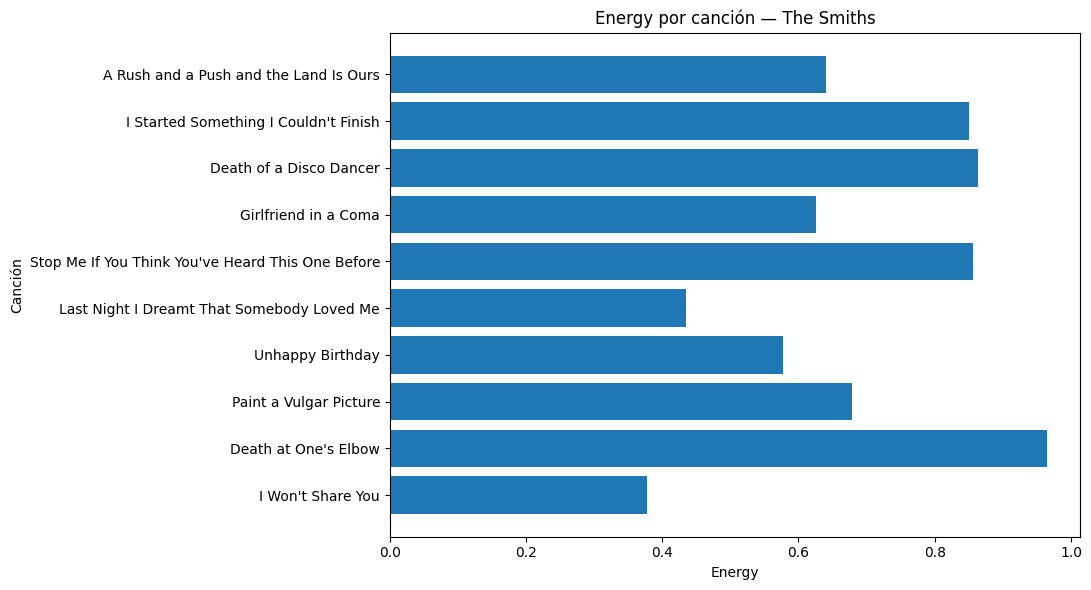

In [7]:
plt.figure(figsize=(11, 6))
plt.barh(studio_df_plot["clean_name"], studio_df_plot["energy"])
plt.xlabel("Energy")
plt.ylabel("Canción")
plt.title("Energy por canción — The Smiths")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Gráfico: Valence por canción

`valence` mide la positividad musical. Valores bajos suelen asociarse con canciones más oscuras o melancólicas.

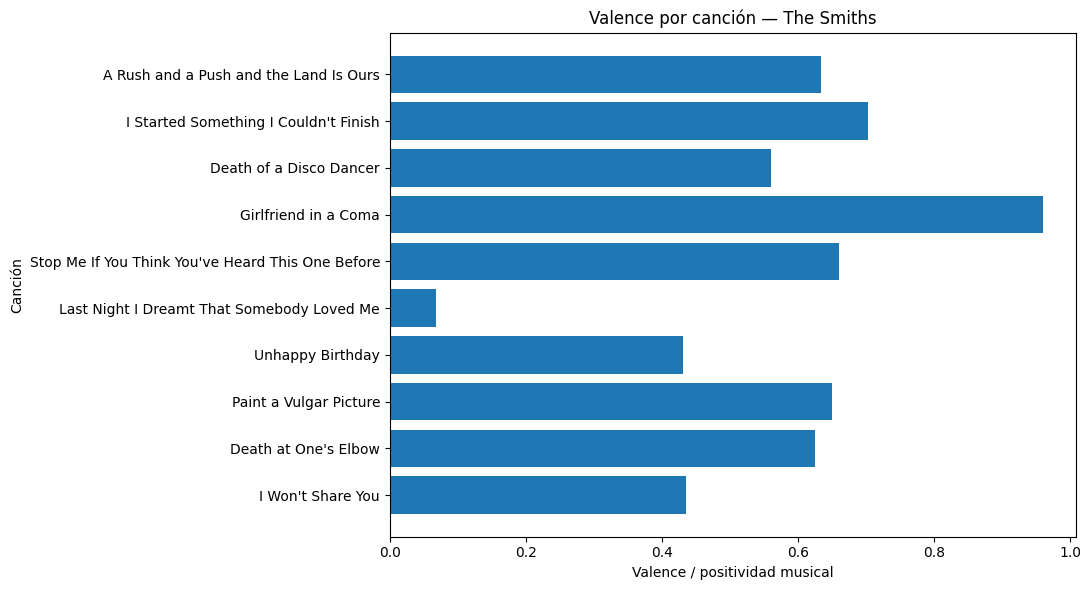

In [8]:
plt.figure(figsize=(11, 6))
plt.barh(studio_df_plot["clean_name"], studio_df_plot["valence"])
plt.xlabel("Valence / positividad musical")
plt.ylabel("Canción")
plt.title("Valence por canción — The Smiths")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Gráfico: Energy vs Valence

Este gráfico permite comparar intensidad y positividad musical en las canciones disponibles.

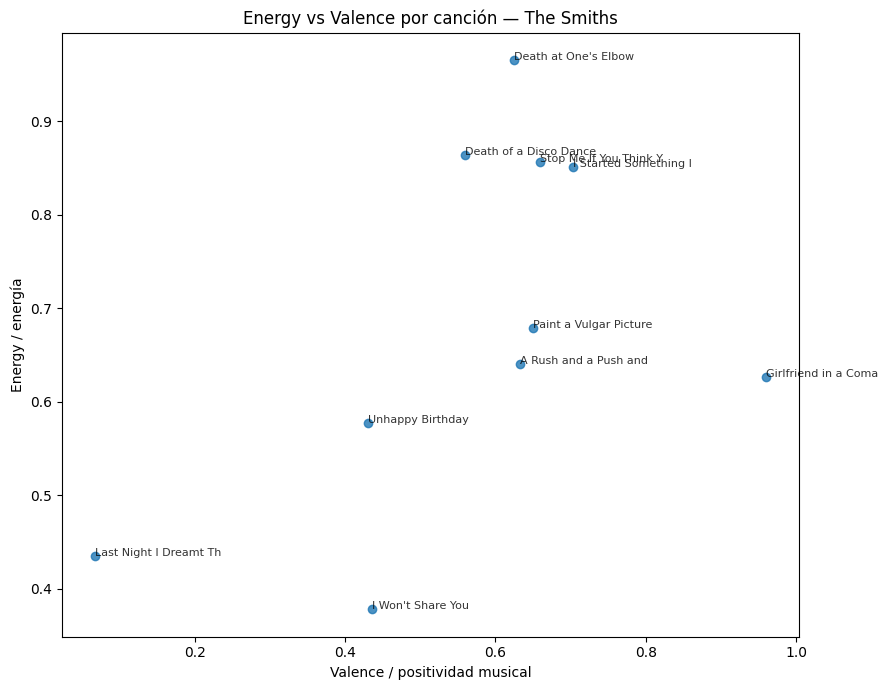

In [9]:
plt.figure(figsize=(9, 7))
plt.scatter(studio_df_plot["valence"], studio_df_plot["energy"], alpha=0.8)

for _, row in studio_df_plot.iterrows():
    plt.text(row["valence"], row["energy"], row["clean_name"][:22], fontsize=8, alpha=0.8)

plt.xlabel("Valence / positividad musical")
plt.ylabel("Energy / energía")
plt.title("Energy vs Valence por canción — The Smiths")
plt.tight_layout()
plt.show()

## 9. Análisis de letras con lyrics.ovh

Se intentó obtener letras de The Smiths con `lyrics.ovh`, pero durante las pruebas la API no devolvió resultados para esas canciones.  
Como el enunciado permite analizar letras de un artista **o de un conjunto de artistas**, se usa un conjunto alternativo de canciones conocidas.

In [10]:
def clean_track_title_for_lyrics(title):
    title = str(title)
    title = re.sub(r"\s*-\s*\d{4}\s*Remaster.*$", "", title, flags=re.IGNORECASE)
    title = re.sub(r"\s*-\s*Remaster.*$", "", title, flags=re.IGNORECASE)
    title = re.sub(r"\s*\(.*?\)", "", title)
    title = re.sub(r"\s*\[.*?\]", "", title)
    title = re.sub(r"\s+", " ", title)
    return title.strip()

def get_lyrics_lyricsovh(artist, title):
    clean_title = clean_track_title_for_lyrics(title)
    url = f"https://api.lyrics.ovh/v1/{requests.utils.quote(artist)}/{requests.utils.quote(clean_title)}"
    try:
        response = requests.get(url, timeout=12)
        if response.status_code == 200:
            data = response.json()
            lyrics = data.get("lyrics")
            if lyrics and len(lyrics.strip()) > 0:
                return lyrics
        return None
    except Exception:
        return None

# Intento inicial con The Smiths
lyrics_rows = []

for _, row in studio_df.head(10).iterrows():
    title = row["clean_name"]
    lyrics = get_lyrics_lyricsovh("The Smiths", title)
    if lyrics:
        lyrics_rows.append({
            "artist": "The Smiths",
            "song": title,
            "source": "The Smiths",
            "lyrics": lyrics,
            "lyrics_length": len(lyrics.split())
        })
    time.sleep(0.2)

lyrics_df = pd.DataFrame(lyrics_rows)
print(f"Letras de The Smiths encontradas: {len(lyrics_df)}")

Letras de The Smiths encontradas: 0


## 10. Conjunto alternativo de artistas para las letras

In [11]:
if lyrics_df.empty:
    lyrics_candidates = [
        {"artist": "Coldplay", "song": "Yellow"},
        {"artist": "Coldplay", "song": "The Scientist"},
        {"artist": "Radiohead", "song": "Creep"},
        {"artist": "Oasis", "song": "Wonderwall"},
        {"artist": "Queen", "song": "Bohemian Rhapsody"},
        {"artist": "Nirvana", "song": "Smells Like Teen Spirit"},
        {"artist": "Adele", "song": "Hello"},
        {"artist": "The Beatles", "song": "Hey Jude"},
        {"artist": "R.E.M.", "song": "Losing My Religion"},
        {"artist": "David Bowie", "song": "Heroes"},
    ]

    alt_rows = []
    for item in lyrics_candidates:
        artist = item["artist"]
        song = item["song"]
        lyrics = get_lyrics_lyricsovh(artist, song)
        if lyrics:
            alt_rows.append({
                "artist": artist,
                "song": song,
                "source": "Conjunto de artistas",
                "lyrics": lyrics,
                "lyrics_length": len(lyrics.split())
            })
        time.sleep(0.2)

    lyrics_df = pd.DataFrame(alt_rows)

print(f"Letras encontradas para el análisis textual: {len(lyrics_df)}")
display(lyrics_df[["artist", "song", "lyrics_length"]])

Letras encontradas para el análisis textual: 9


,artist,song,lyrics_length
0,Coldplay,Yellow,204
1,Coldplay,The Scientist,189
2,Radiohead,Creep,166
3,Oasis,Wonderwall,267
4,Queen,Bohemian Rhapsody,394
5,Nirvana,Smells Like Teen Spirit,253
6,Adele,Hello,365
7,The Beatles,Hey Jude,202
8,David Bowie,Heroes,266


## 11. Gráfico: palabras más frecuentes

Se eliminan palabras muy comunes para visualizar mejor el vocabulario dominante en las letras recuperadas.

,word,frequency
0,hello,45
1,i'm,23
2,don't,21
3,one,18
4,you're,16
5,highs,16
6,lows,16
7,here,15
8,now,14
9,nothing,14


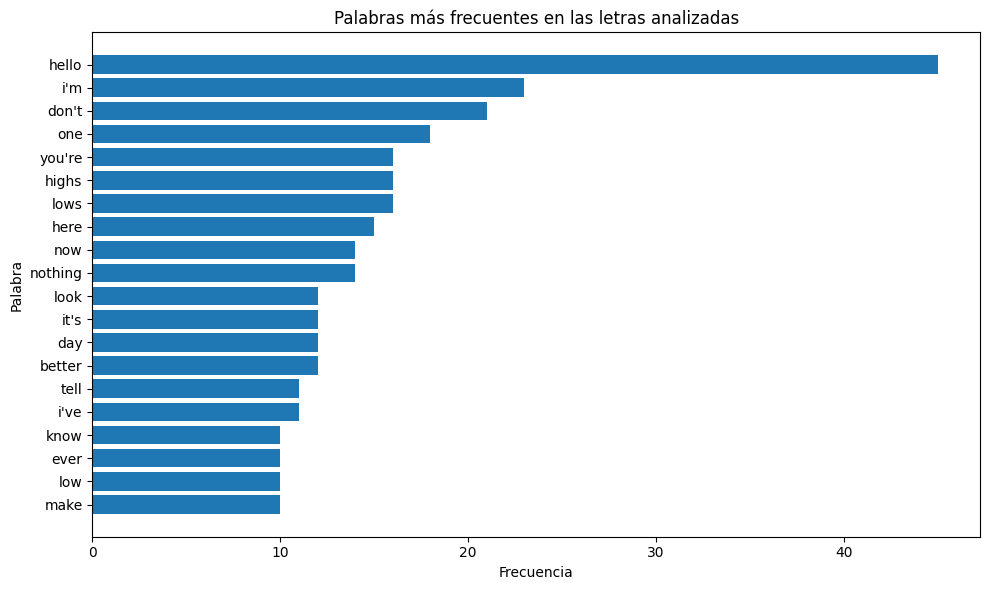

In [12]:
STOPWORDS = {
    "the", "and", "you", "your", "that", "this", "with", "for", "are",
    "was", "were", "but", "not", "have", "has", "had", "they", "them",
    "his", "her", "she", "him", "our", "out", "all", "can", "will",
    "just", "from", "there", "what", "when", "where", "who", "why",
    "how", "into", "about", "over", "under", "then", "than", "too",
    "i", "me", "my", "we", "us", "a", "an", "of", "to", "in", "on",
    "it", "is", "be", "am", "do", "so", "no", "yes", "oh", "la",
    "na", "yeah", "hey", "got", "get", "let"
}

def tokenize_lyrics(text):
    text = str(text).lower()
    words = re.findall(r"[a-zA-Z']+", text)
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

all_words = []
for lyrics in lyrics_df["lyrics"]:
    all_words.extend(tokenize_lyrics(lyrics))

word_counts = Counter(all_words)
words_df = pd.DataFrame(word_counts.most_common(20), columns=["word", "frequency"])

display(words_df)

plt.figure(figsize=(10, 6))
plt.barh(words_df["word"], words_df["frequency"])
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.title("Palabras más frecuentes en las letras analizadas")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 12. Nube de palabras

La nube de palabras ayuda a identificar visualmente las palabras más frecuentes.

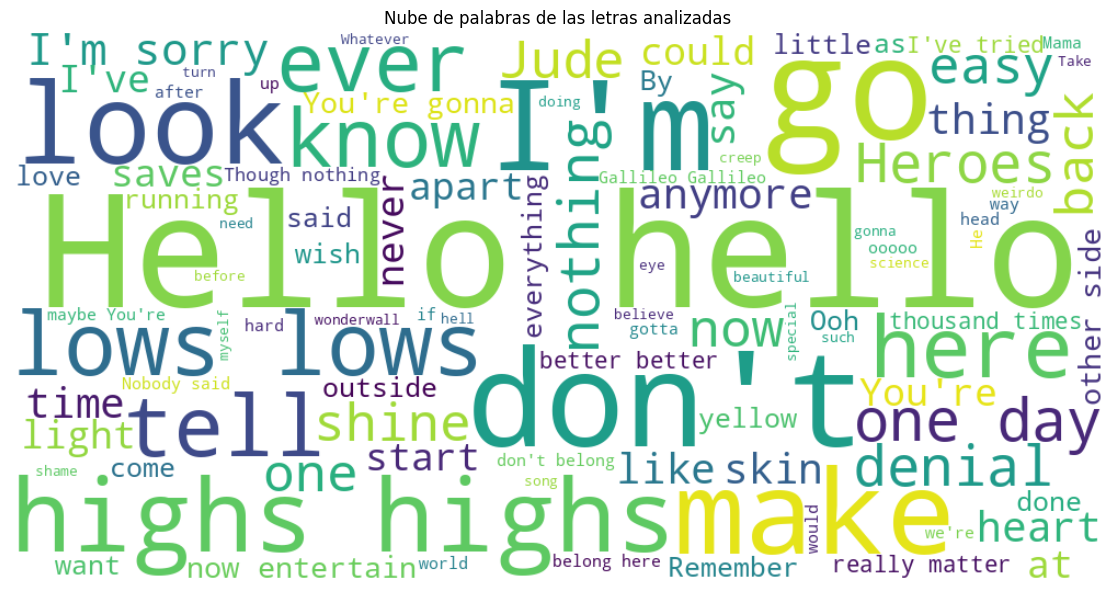

In [13]:
text_for_wordcloud = " ".join(lyrics_df["lyrics"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=STOPWORDS,
    max_words=100
).generate(text_for_wordcloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de las letras analizadas")
plt.tight_layout()
plt.show()

## 13. Web app Streamlit

Además del notebook, se ha creado una web app con Streamlit para explorar los componentes implementados.

https://5mbkvc4sqvcmbqokwmnsou.streamlit.app/

La app permite explorar canciones, variables musicales, análisis de letras y gráficos.

## 14. Conclusiones

El proyecto cumple los tres apartados del enunciado:

1. Se filtraron los álbumes de estudio de The Smiths usando una lista basada en su discografía oficial.
2. Se incorporaron gráficos relacionados con letras: frecuencia de palabras y nube de palabras.
3. Se creó una web app en Streamlit para explorar los resultados.

Una conclusión importante es que el dataset usado solo contiene canciones originales de The Smiths del álbum `Strangeways, Here We Come`. Por eso, los gráficos musicales se realizaron por canción y no por álbum.